#  Tokenization & Word Embeddings

Сегодня мы начинаем работать с текстами. Первый шаг любого пайплайна для обработки текстов на естественных языках (NLP, natural language processing) — это векторизация текстов или их составляющих (буквосочетаний, слов, словосочетаний). Иными словами, перевод текстов из формы последовательности букв/слов/токенов в числовые векторы. Такие векторы обычно называют эмбеддингами. Для задач NLP (part of speech tagging, named entity recognition, генерация текста, etc.) бывает полезно пользоваться готовыми эмбеддингами, полученными за нас. Далее, при решении конкретной задачи, слова в текстах заменяют готовыми эмбеддингами и поверх этого дела уже строят разные модели.

Наша цель — получить векторные представления одинакового размера для каждого слова из словаря. При этом перед обработкой слов из текста моделью, мы хотим по номеру слова в словаре брать из таблицы эмбеддингов нужный вектор и далее работать с ним как с признаковым описанием слова.

В идеале, мы хотим, чтобы полученные эмбеддинги отражали какое-то отношение между словами (семантику). Условно, мы хотим, чтобы векторы слов "любить" и "обожать" были ближе, чем векторы слов "любить" и "география" (за исключением, пожалуй, случаев, когда тексты, на которых мы учили представления, рассказывают о страстной любви к географии), но обо всём по порядку:

### План на сегодня:
1. Предобработка текста:
   * Токенизация
   * Стемминг
   * Лемматизация

2. Простая классификация:
   * TF-IDF

3. Word2Vec



In [79]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

In [80]:
data = list(open("quora.txt"))
data[50]

"What TV shows or books help you read people's body language?\n"

## 1. Предобработка текста

Мы выполняем предобработку текста, чтобы превратить неструктурированный, написанный человеком язык в последовательный и удобный для модели ввод.

Предобработка включает:

* токенизацию
* приведение к нижнему регистру
* нормализацию пунктуации и пробелов
* обработку стоп-слов
* лемматизацию/стемминг.

Эти шаги позволяют уменьшить размер словаря, снизить разреженность и удалить ненужные слова, чтобы уменьшить шум и позволить модели улавливать смысл, а не особенности форматирования. Это улучшает обобщающую способность модели (меньше дубликатов вроде “cat/Cat/CATS” или "выйти/вышел/вышла/выйду"), делает обучение быстрее и стабильнее.

Главное — умеренность: очищайте только то, что реально вредит качеству (например, HTML-разметку, дубликаты, очевидный шум), но сохраняйте семантику (отрицания, эмодзи, регистр — если он важен), чтобы не "убить" сам сигнал, который модель должна выучить.


### 1.1. Токенизация

Токенизация — это процесс разделения текста на токены (наборы символов). Совокупность всех полученных токенов образует наш словарь, на котором мы будем обучать модель.

Сегодня мы рассмотрим метод токенизации по словам (одно слово == один токен). Позже в курсе мы познакомимся и с другими вариантами токенизации, при которых токен — это не обязательно целое слово, а иногда лишь его часть.

In [81]:
import re
from string import punctuation
punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [82]:
def tokenize(text):
    for p in punctuation:
        text = text.replace(p, ' ')

    text = text.strip().split()
    return text

In [83]:
print(tokenize(data[50]))

['What', 'TV', 'shows', 'or', 'books', 'help', 'you', 'read', 'people', 's', 'body', 'language']


**`nltk`** — это большая библиотека (сопоставимая с `numpy` для работы с матрицами). В ней реализованы методы для [токенизации](https://www.nltk.org/api/nltk.tokenize.html), [лемматизации](https://www.nltk.org/api/nltk.stem.wordnet.html), [стемминга](https://www.nltk.org/api/nltk.stem.html) и многих других задач.

In [84]:
#!pip install nltk

In [85]:
from nltk.tokenize import wordpunct_tokenize

print(wordpunct_tokenize(data[50]))

['What', 'TV', 'shows', 'or', 'books', 'help', 'you', 'read', 'people', "'", 's', 'body', 'language', '?']


**ЗАДАЧА**: привести весь текст к нижнему регистру и разделить его на токены

In [ ]:
data_tok = # YOUR CODE HERE

In [87]:
assert all(isinstance(row, (list, tuple)) for row in data_tok), "please convert each line into a list of tokens (strings)"
assert all(all(isinstance(tok, str) for tok in row) for row in data_tok), "please convert each line into a list of tokens (strings)"
is_latin = lambda tok: all('a' <= x.lower() <= 'z' for x in tok)
assert all(map(lambda l: not is_latin(l) or l.islower(), map(' '.join, data_tok))), "please make sure to lowercase the data"

In [88]:
print(data_tok[:2])

[['can', 'i', 'get', 'back', 'with', 'my', 'ex', 'even', 'though', 'she', 'is', 'pregnant', 'with', 'another', 'guy', 's', 'baby'], ['what', 'are', 'some', 'ways', 'to', 'overcome', 'a', 'fast', 'food', 'addiction']]


### 1.2. Убираем стоп-слова

Часто встречающиеся слова (например "the", "of", "for", etc.) не обеспечивают особого контекста для близлежащих слов. Если мы отбросим некоторые из них, мы сможем удалить часть шума из наших данных и взамен получить более быстрое обучение и лучшее представление.

In [89]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/pavelmaltsev/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [90]:
from nltk.corpus import stopwords

stop_words = stopwords.words('english')
print(stop_words)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [ ]:
def remove_stopwords(tokenized_texts):
    clear_texts = []
    # YOUR CODE HERE

    return clear_texts

In [92]:
data_tok = remove_stopwords(data_tok)

In [93]:
print(data[50])
print(data_tok[50])

What TV shows or books help you read people's body language?

['tv', 'shows', 'books', 'help', 'read', 'people', 'body', 'language']


### 1.3. Лемматизация и стемминг

#### Лемматизация

**Лемматизация** — это процесс приведения слова к его канонической словарной форме (**лемме**):

* для существительных — именительный падеж, единственное число;
* для прилагательных — именительный падеж, единственное число, мужской род;
* для глаголов, причастий, деепричастий — форма инфинитива.

Для английского языка — `nltk.stem.WordNetLemmatizer`.
Для русского языка — `pymorphy2.MorphAnalyzer`.

Лемматизация — очень распространённый способ уменьшить размер словаря в классических NLP-пайплайнах.


#### Стемминг

**Стемминг** — это процесс приведения слова к его **основе (стему)** путём эвристического удаления приставок и суффиксов.
Он **не** гарантирует получение реального слова из словаря и, как правило, игнорирует часть речи и грамматику.

* Нет грамматической нормализации (только обрезка аффиксов).
* Результат может быть «не-словом» (например, `studies` → `studi`, `кошками` → `кошк`).
* Очень быстрый метод; часто сильнее сокращает словарь, но может объединять несвязанные формы и снижать точность.

Для английского языка — `nltk.stem.PorterStemmer`, `nltk.stem.SnowballStemmer("english")`.
Для русского языка — `nltk.stem.SnowballStemmer("russian")` (или другие реализации на основе Snowball).

#### Примеры

##### Английский:

| Исходная форма(ы) | Стемминг (алгоритм)        | Лемма (лемматизация) |
| ----------------- | -------------------------- | -------------------- |
| `studies`         | `studi` (Porter)           | `study`              |
| `goes`, `going`   | `go` (Porter)              | `go`                 |
| `went`            | `went` (Porter)            | `go`                 |
| `better` (прил.)  | `better` / `bett` (Porter) | `good`               |

##### Русский:

| Исходная форма(ы)           | Стемминг (алгоритм)         | Лемма (лемматизация) |
| --------------------------- | --------------------------- | -------------------- |
| `кошки`, `кошек`, `кошками` | `кошк` (Snowball)           | `кошка`              |
| `читал`, `читала`, `читали` | `чит` (Snowball)            | `читать`             |
| `дети`                      | `дет` (Snowball)            | `ребёнок`            |
| `лучше`                     | `лучш` / `лучше` (Snowball) | `хорошо` / `хороший` |

#### Когда что использовать?

*Стемминг*: быстрый, подходит для поисковых систем, где важна полнота; ожидается шум (`studi`, `comput`).
*Лемматизация*: медленнее и тяжелее, но обеспечивает более высокую точность и лучшее понимание смысла — особенно важна для морфологически богатых языков (например, русского) и при работе с исключениями/нерегулярностями (неправильные глаголы, исключение в правилах склонения).


In [94]:
import nltk
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/pavelmaltsev/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [95]:
from nltk.stem import WordNetLemmatizer

def lemmatize_text(tokenized_texts):
    lemmatized_data = []
    lemmatizer = WordNetLemmatizer()
    for words in tqdm(tokenized_texts):
        lemmatized_words = [lemmatizer.lemmatize(word) for word in words]
        lemmatized_data.append(lemmatized_words)
    return lemmatized_data

In [96]:
from nltk.stem import PorterStemmer

def text_stemming(tokenized_texts):
    stemmed_data = []
    stemmer = PorterStemmer()
    for words in tqdm(tokenized_texts):
        stemmed_words = [stemmer.stem(word) for word in words]
        stemmed_data.append(stemmed_words)
    return stemmed_data

In [97]:
lemmatized_data = lemmatize_text(data_tok)
stemmed_data = text_stemming(data_tok)

100%|██████████| 537272/537272 [00:23<00:00, 23158.46it/s]


In [98]:
print(lemmatized_data[50])
print(stemmed_data[50])

['tv', 'show', 'book', 'help', 'read', 'people', 'body', 'language']
['tv', 'show', 'book', 'help', 'read', 'peopl', 'bodi', 'languag']


Иногда достаточно полезно проверить облако слов, когда работаем с текстовыми данными:
- проверить stopwords
- ошибки, шум и тд

In [99]:
# !pip install wordcloud

In [100]:
from wordcloud import WordCloud

def create_cloud_graph(corpus):
    wordcloud = WordCloud(
        width=1600, height=800, max_words=200, background_color='white', collocations=False
    ).generate(' '.join(corpus))
    plt.figure(figsize=(20,10))
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.show()

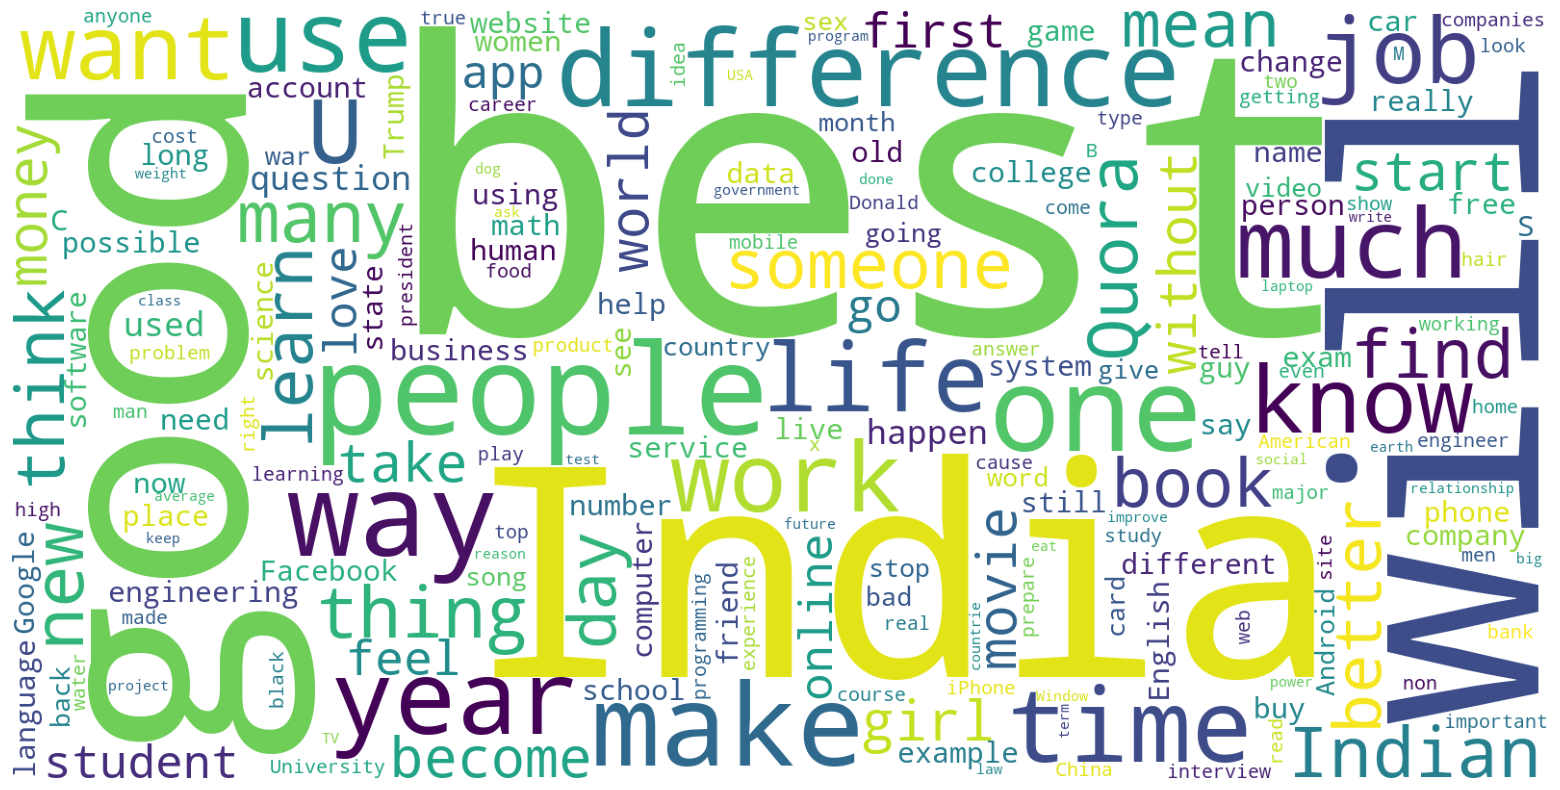

In [78]:
create_cloud_graph(data)

## 2. Word Embeddings

>*Отличная статья по word2Vec: [illustrated word2vec by Jay Alammar](https://jalammar.github.io/illustrated-word2vec/)*


>*и посмотреть вот это видео о том, как обучается Word2Vec на примере Skip-Gram: [Word Vector Representations: word2vec by Stanford](https://youtu.be/ERibwqs9p38)*

Для создания эмбеддингов будем использовать `Word2Vec` из библиотеки [`gensim`](https://radimrehurek.com/gensim/auto_examples/). 

In [47]:
#! pip install gensim==4.4.0

In [101]:
from gensim.models import Word2Vec
model = Word2Vec(data_tok,
                 vector_size=32,   # embedding vector size
                 min_count=5,      # consider words that occured at least 5 times
                 window=5).wv      # define context as a 5-word window around the target word

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [49]:
# now you can get word vectors!
model.get_vector('word')

array([ 0.2796532 , -1.1168835 , -0.09128721, -2.0012443 ,  1.0370148 ,
       -2.148426  , -0.98889446,  1.637871  ,  1.0150915 ,  0.16156615,
       -0.898029  , -3.546667  , -3.003758  , -1.4529457 , -0.41023207,
        0.7528465 ,  0.1479785 ,  2.3188016 ,  1.2832834 , -2.259088  ,
        1.7384062 ,  2.2518039 ,  1.0297786 ,  1.059318  , -0.43386284,
        3.56451   , -2.372344  ,  0.02853939,  0.13952446, -0.4175641 ,
       -0.89644504,  1.9543456 ], dtype=float32)

In [50]:
# or find similar words directly!
model.most_similar('word')

[('phrase', 0.8456023931503296),
 ('slang', 0.8097897171974182),
 ('sentences', 0.7902542948722839),
 ('sentence', 0.7862855792045593),
 ('words', 0.7801639437675476),
 ('verb', 0.7776660919189453),
 ('phrases', 0.7775278091430664),
 ('idiom', 0.7741888761520386),
 ('singular', 0.7668923139572144),
 ('incorrect', 0.7512015700340271)]

Вместо того чтобы обучать модель с нуля, мы можем загрузить **предобученные эмбеддинги**, полученные при обучении на гигабайтах текстов.

Обучение эмбеддингов всегда требует много времени, поэтому гораздо удобнее использовать уже готовые.

In [51]:
import gensim.downloader as api
model = api.load('glove-twitter-100')

Оказалось, наши эмбеддинги имеют линейную структуру:

In [102]:
model.most_similar(positive=["woman", "king"], negative=["man"])

[('prince', 0.8800663352012634),
 ('queen', 0.8639015555381775),
 ('jr', 0.8387777209281921),
 ('luther', 0.8260195851325989),
 ('lee', 0.8259257078170776),
 ('winston', 0.8252407312393188),
 ('macbeth', 0.8225738406181335),
 ('princess', 0.8174147009849548),
 ('18th', 0.817231297492981),
 ('zeitgeist', 0.8140344619750977)]

In [53]:
model.most_similar(positive=["latte", "water"], negative=["milk"])

[('macchiato', 0.6081759333610535),
 ('cappuccino', 0.5919400453567505),
 ('warm', 0.5744419693946838),
 ('espresso', 0.572758674621582),
 ('coffee', 0.5530275702476501),
 ('iced', 0.5521673560142517),
 ('mist', 0.5395066142082214),
 ('light', 0.5311260223388672),
 ('mocha', 0.5279608964920044),
 ('breeze', 0.5279031991958618)]

In [103]:
model.most_similar(positive=['head', 'sock'], negative=['foot'])

[('chun', 0.8492192625999451),
 ('pumpkins', 0.8342683911323547),
 ('contempt', 0.8224337100982666),
 ('horn', 0.8190375566482544),
 ('raining', 0.8125545978546143),
 ('gasket', 0.8122694492340088),
 ('fandom', 0.8120450377464294),
 ('deterioration', 0.8103960156440735),
 ('protinex', 0.8100898265838623),
 ('tract', 0.8098271489143372)]